# Análisis y visualización de datos con python
# 10. Estadística básica

    - a) Frecuencia
    - b) Distribuciones estadísticas
    - c) Promedio, mediana y moda
    - d) Asimetría
    - e) Desviación estándar y desviación mediana absoluta
    - f) Valores atípicos
    - g) Pruebas de distribución
    - h) Resumen
    
--- 

Empezaremos cargando los datos en formato pickle para asegurarnos que los tipos de datos se respeten.

In [1]:
import pandas as pd
import numpy as np
import scipy.stats as stats

import matplotlib.pyplot as plt
import seaborn as sns

from joblib import load

in_file = "data_clean/HBO_clean.pkl"
with open(in_file, 'rb') as f:
     df = load(f)
df.tail()


,ID,Nombre_completo_transcrito,Primer_apellido,Segundo_apellido,Nombres_propios,Fecha_transcrito,Fecha_estandar,Fecha_año,Fecha_mes,Fecha_diasemana,...,Diagnostico_transcrito,Diagnostico_estandar,Diagnostico_extendido,Diagnostico_clasificacion,Sexo,Edad_transcrito,Edad_estandar,Edad_grupo,Tipo_restos,Conocido_desconocido
96839,BO_1982_07489,placenta,NaN,NaN,NaN,1982-06-05,1982-06-05,1982.0,6.0,Sábado,...,S-D,NaN,NaN,NaN,S-D,S-D,NaN,NaN,Miembros u óseos,Desconocido
96840,BO_1982_07490,5 dedos del pie derecho de desconocido,NaN,NaN,NaN,1982-06-05,1982-06-05,1982.0,6.0,Sábado,...,S-D,NaN,NaN,NaN,S-D,S-D,NaN,NaN,Miembros u óseos,Desconocido
96841,BO_1982_07491,dedo de desconocido,NaN,NaN,NaN,1982-11-19,1982-11-19,1982.0,11.0,Viernes,...,S-D,NaN,NaN,NaN,S-D,S-D,NaN,NaN,Miembros u óseos,Desconocido
96842,BO_1982_07492,4 dedos de desconocido,NaN,NaN,NaN,1982-11-28,1982-11-28,1982.0,11.0,Domingo,...,S-D,NaN,NaN,NaN,S-D,S-D,NaN,NaN,Miembros u óseos,Desconocido
96843,BO_1982_07493,osamenta de desconocido,NaN,NaN,NaN,1982-10-11,1982-10-11,1982.0,10.0,Lunes,...,S-D,NaN,NaN,NaN,S-D,S-D,NaN,NaN,Cadáver,Desconocido


## 10.a Frecuencia

La **población estadística** es el conjunto completo de elementos (personas, objetos, eventos, etc.) que tienen una característica en común y sobre los que se desea obtener información. Puede ser finita o infinita. Por ejemplo, nuestra población puede ser todas las personas vivas en México o todos los ingresos al SEMEFO-DF de 1968 a 1982. Una **muestra estadística** es un subconjunto representativo de la población, que se selecciona para estudiar una o varias características sin necesidad de analizar a toda la población. Idealmente, se obtiene de forma aleatoria, aunque generalmente hay sesgos asociados al muestreo.

Por otro lado, la **frecuencia** de un evento es el número de veces en que dicho evento se repite durante un experimento o muestra estadística. Comúnmente, la distribución de la frecuencia suele visualizarse con una tabla de conteo o un histograma.

Por ejemplo, para ver la frecuencia de las edades podemos usar la función `.value_counts()` la cual cuenta cuantas veces aparece cada valor. Esta función nos regresa los valores ordenados de más frecuente a menos frecuente. 

Podemos ordenar esta tabla por las edades, las cuales se encuentran en el índice, para ver las frecuencias de las edades.
Sin embargo, esta función no incluye las edades que no aparecen, por ejemplo, 2 años.

In [2]:
edad_freq = df['Edad_estandar'].value_counts().sort_index()
edad_freq

Edad_estandar
0.0     2599
1.0      418
1.5       31
2.0      585
2.2        1
        ... 
95.0      19
96.0       8
97.0       6
98.0       9
99.0       2
Name: count, Length: 119, dtype: int64

Graficando se puede notar varias cosas. 
Por ejemplo, la edad que se encuentra más veces es 0, seguida de 40. Tenemos pocos cuerpos de menos de 20 años, además las edades que terminan en cinco son más comunes.

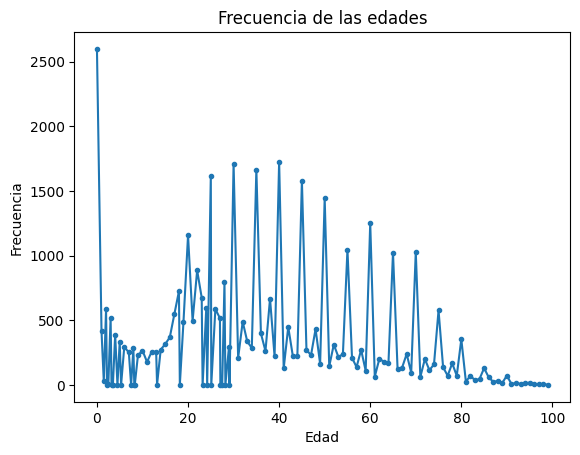

In [3]:
edad_freq.plot(style='.-', title="Frecuencia de las edades",
               xlabel='Edad', ylabel='Frecuencia'
              )
plt.show()

Otro ejemplo son los ingresos por día. En primer lugar, contemos cuantos ingresos hubo cada día a lo largo del periodo. Esto se conoce como serie de tiempo, y podemos ver que la cantidad de ingresos diarios varía fuertemente.

<Axes: xlabel='Fecha_estandar'>

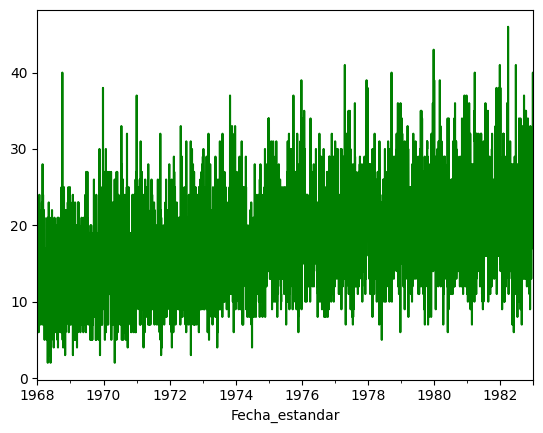

In [4]:
ingresos_diarios = df['Fecha_estandar'].value_counts().sort_index()
ingresos_diarios.plot(color='g')

A continuación contemos cuantos días hay con N ingresos. La mayor parte de los días hubo alrededor de 18 ingresos, aunque hay días con muy pocos o muchos.

<Axes: xlabel='count'>

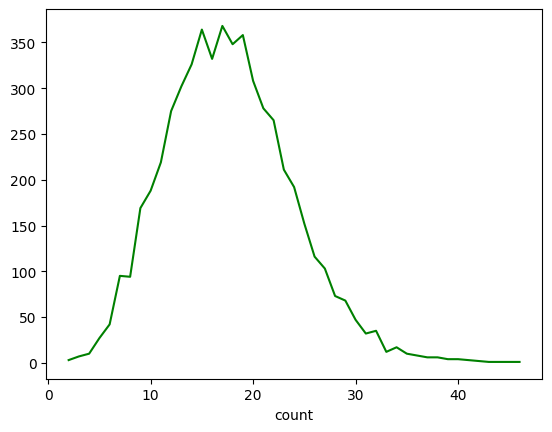

In [5]:
ingresos_freq = ingresos_diarios.value_counts().sort_index()
ingresos_freq.plot(color='g')

## 10.b Distribuciones estadísticas

La distribución de un conjunto de datos es la forma en que los datos se agrupan y se distribuyen a lo largo de un rango de valores. La distribución puede ser discreta o continua, simétrica o asimétrica, y puede tener una o varias modas o picos.

Las distribuciones continuas más comunes son la distribución uniforme, normal y  exponencial.

**Distribución uniforme**: Es una distribución de probabilidad en la que todos los valores posibles tienen la misma probabilidad de ocurrir. Es decir, la probabilidad de que un valor se encuentre en cualquier intervalo de la distribución es proporcional al tamaño del intervalo. Por ejemplo, si se lanza un dado justo, la probabilidad de obtener cualquier número del 1 al 6 es igual.  
![Distribución uniforme](images/320px-Uniform_distribution_PDF.png)

**Distribución normal**: También conocida como distribución Gaussiana, es una distribución de probabilidad en la que los valores se agrupan alrededor de la media y tienen una forma de campana simétrica. Muchas variables en la naturaleza, como la altura o el peso, siguen una distribución normal. En esta distribución, la media y la desviación estándar son los parámetros principales que describen la distribución.  
![Distribución normal](images/320px-Normal_distribution_pdf.png)

**Distribución exponencial**: Es una distribución de probabilidad que se utiliza para modelar el tiempo que transcurre entre eventos sucesivos e independientes. Por ejemplo, el tiempo que transcurre entre dos terremotos o el tiempo que transcurre entre dos llamadas telefónicas. En esta distribución, el parámetro principal es la tasa de eventos, que es el número promedio de eventos que ocurren por unidad de tiempo.  
![Distribución exponencial](images/300px-Exponential_pdf.svg.png)

También es importante reconocer la distribución bimodal y log-normal.

**Distribución bimodal**: Es una distribución de probabilidad con dos modas. Es un caso particular de las distribuciones bimodales. Por ejemplo, el tráfico sigue una distribución bimodal, con dos picos, uno en la mañana y otro en la tarde. Esta distribución puede ser el resultado de la suma de dos distribuciones normales.    
![Distribución bimodal](images/Bimodal_geological.png)

**Distribución log-normal**: Es una distribución de probabilidad de una variable cuyo logaritmo está normalmente distribuido. Esta es una distribución de importancia en ingeniería, medicina y biología.  
![Distribución log-normal](images/Log-normal-pdfs.png)

Dos ejemplos de distribuciones discretas son binomial y Poisson.

**Distribución Binomial** Es una distribución de probabilidad que se utiliza para modelar el número de éxitos en una secuencia de ensayos independientes con dos posibles resultados (éxito o fracaso), cada uno con la misma probabilidad. Por ejemplo, lanzar una moneda y contar cuántas veces sale cara. En esta distribución, el parámetro principal es la probabilidad de éxito.  
![Distribución binomiall](images/Binomial_distribution_pmf.svg)

**Distribución Poisson**: Es una distribución de probabilidad que se utiliza para modelar el número de eventos raros que ocurren en un intervalo de tiempo o espacio determinado. Por ejemplo, el número de llamadas de emergencia que recibe una central telefónica en una hora o el número de accidentes de tráfico que ocurren en una intersección durante un mes. En esta distribución, el parámetro principal es la tasa de eventos, que es el número promedio de eventos que ocurren en un intervalo de tiempo o espacio determinado.  
![Distribución poisson](images/Poisson_pmf.svg.png)


Cada una de estas distribuciones de probabilidad se utiliza para modelar diferentes tipos de datos y situaciones en estadística y tienen sus propias propiedades y características.
Es importante comprender la distribución de los datos porque puede afectar cómo se analizan y se interpretan. Por ejemplo, si los datos se distribuyen normalmente, se pueden utilizar pruebas estadísticas específicas para analizarlos, mientras que si los datos tienen una distribución asimétrica, puede ser necesario utilizar diferentes técnicas de análisis.


## 10.c Promedio, mediana y moda

El **promedio o media** de un conjunto de datos se encuentra al sumar todos los números en el conjunto de datos y luego al dividir entre el número de valores en el conjunto. 

La **mediana** es el valor medio cuando un conjunto de datos se ordena de menor a mayor. Se recomienda usar esta medida estadística cuando los datos tienen valores atípicos o _outliers_, los cuales pueden sesgar el valor del promedio.

La **moda** es el valor más común en el conjunto de datos. Este es el valor que esperaríamos encontrar hasta arriba de la función `.value_counts()`, ya que su frecuencia es la más alta. Es posible que una misma serie de datos tenga más de una moda cuando la frecuencia de varios valores es la misma.

In [6]:
edad_media = df['Edad_estandar'].mean().round(4)
edad_mediana = df['Edad_estandar'].median()
edad_moda = df['Edad_estandar'].mode()[0]

print(f"Edad_estandar\n\tmedia: {edad_media}\n\tmediana: {edad_mediana}\n\tmoda: {edad_moda}")

Edad_estandar
	media: 35.2095
	mediana: 34.0
	moda: 0.0


Grafiquemos los tres valores con la frecuencia de las edades.

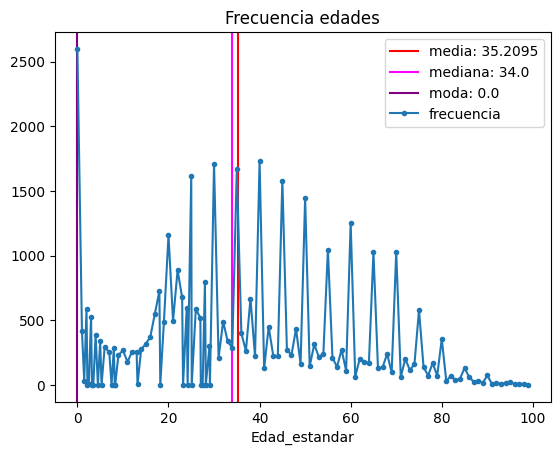

In [7]:
# graficas de las medidas estadísticas
plt.axvline( edad_media, color="red", label=f"media: {edad_media}")
plt.axvline( edad_mediana, color="magenta", label=f"mediana: {edad_mediana}")
plt.axvline( edad_moda, color="purple", label=f"moda: {edad_moda}")
# grafica de la frecuencia de las edades
edad_freq.plot(style='.-', title="Frecuencia edades", label="frecuencia")
# Leyenda y mostrar gráfica
plt.legend()
plt.show()

Repitamos el mismo proceso para la distribución de ingresos diarios.

In [8]:
ingresos_media = ingresos_diarios.mean().round(4)
ingresos_mediana = ingresos_diarios.median()
ingresos_moda = ingresos_diarios.mode()[0]

print(f"Ingresos diarios\n\tmedia: {ingresos_media}\n\tmediana: {ingresos_mediana}\n\tmoda: {ingresos_moda}")

Ingresos diarios
	media: 17.6271
	mediana: 17.0
	moda: 17


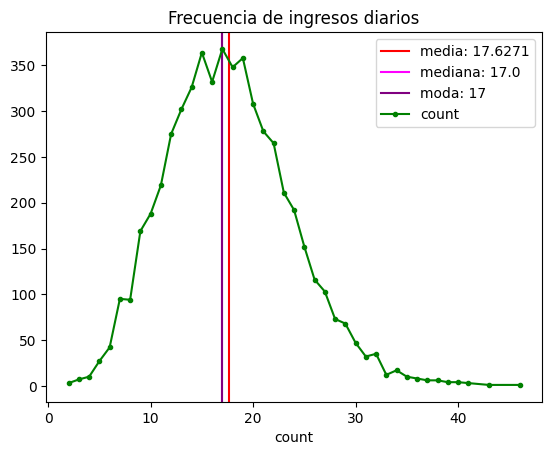

In [9]:
# graficas de las medidas estadísticas
plt.axvline( ingresos_media, color="red", label=f"media: {ingresos_media}")
plt.axvline( ingresos_mediana, color="magenta", label=f"mediana: {ingresos_mediana}")
plt.axvline( ingresos_moda, color="purple", label=f"moda: {ingresos_moda}")
# grafica de la frecuencia de ingresos
ingresos_freq.plot(color='g', style='.-', title="Frecuencia de ingresos diarios")
# Leyenda y mostrar gráfica
plt.legend()
plt.show()

## 10.d Asimetría

El **asimetría** indica si los datos se concentran en un lado de la curva. Se obtiene usado la función `.skew()`.
* Una asimetría negativa ($asim<0$) implica que hay más valores distintos a la izquierda del promedio (media). 
* Una asimetría cero ($asim=0$)  implica que hay la misma cantidad de valores de ambos lados del promedio (media).
* Una asimetría positiva ($asim>0$) implica que hay más valores distintos a la derecha del promedio (media).

Por ejemplo, viendo las edades podemos notar que hay más registros de personas de edad avanzada que de niños, por lo que la gráfica tiene un sesgo hacia la derecha. Por lo tanto, esperamos que la asimetría sea positiva.

In [10]:
df['Edad_estandar'].skew()

np.float64(0.25745377072403425)

Si nos centramos solo en los cadáveres, la distribución debe de pesar aún más hacia la derecha.

In [11]:
df.loc[df['Tipo_restos']=='Cadáver','Edad_estandar'].skew()

np.float64(0.2716473697049317)

Para ingresos diarios

In [12]:
ingresos_diarios.skew()

np.float64(0.43131654165750644)

Cuando los datos tienen muchos picos, como es el caso con las edades, puede ayudar verlos con un KDE o histograma.

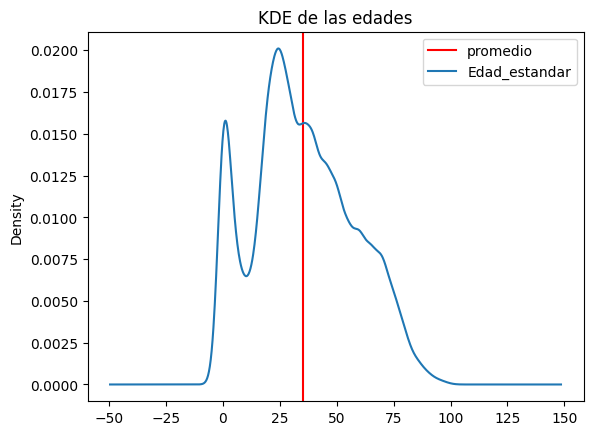

In [13]:
# graficas de las medidas estadísticas
plt.axvline(df['Edad_estandar'].mean(), color="red", label="promedio")
# grafica de la frecuencia de las edades
df['Edad_estandar'].plot.kde(title="KDE de las edades")
# Leyenda y mostrar gráfica
plt.legend()
plt.show()

Veamos los ingresos diarios con un histograma.

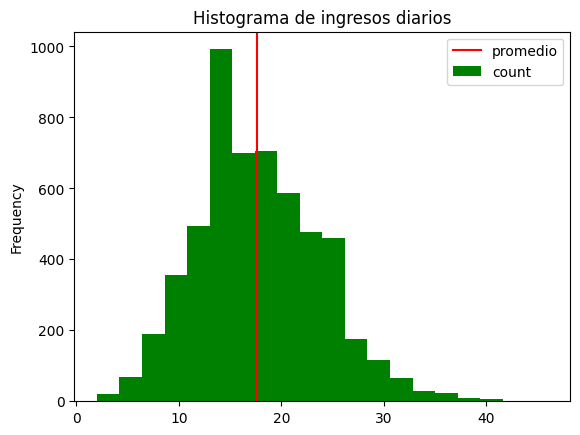

In [14]:
# graficas de las medidas estadísticas
plt.axvline(ingresos_diarios.mean(), color="red", label="promedio")
# grafica de la frecuencia de las edades
ingresos_diarios.plot.hist(bins=20, color='g', title="Histograma de ingresos diarios")
# Leyenda y mostrar gráfica
plt.legend()
plt.show()

Cada visualización tiene sus ventajas y desventajas, por lo que es importante explorar los datos de diversas maneras y verificar las intuiciones visuales con estadísticas.

## 10.e Desviación estándar y desviación mediana absoluta

La **varianza** es una medida estadística que representa la dispersión de un conjunto de datos alrededor de su media o valor promedio. La varianza se expresa en unidades al cuadrado, lo que significa que no tiene las mismas unidades que los datos originales. 

Para obtener una medida más interpretable, se puede tomar la raíz cuadrada de la varianza, lo que resulta en la **desviación estándar**. La desviación estándar es una medida de dispersión más comúnmente utilizada que la varianza, ya que tiene las mismas unidades que los datos originales y es más fácil de interpretar.

In [15]:
df['Edad_estandar'].std()

np.float64(22.09351505253416)

Una desviación estándar alta indica que los datos están más dispersos, mientras que una desviación estándar baja indica que los datos están más agrupados alrededor de la media.

Cuando un valor está a más de una desviación estándar de la media, significa que se encuentra en el extremo de la distribución de los datos. En una distribución normal, aproximadamente el 68% de los datos se encuentran dentro de una desviación estándar de la media, mientras que el 32% restante se encuentra fuera de esta zona.

En muchos casos esto no se cumple, por ejemplo, tenemos una gran cantidad de edades menores de tres años, lo cual hace que la distribución no sea normal.

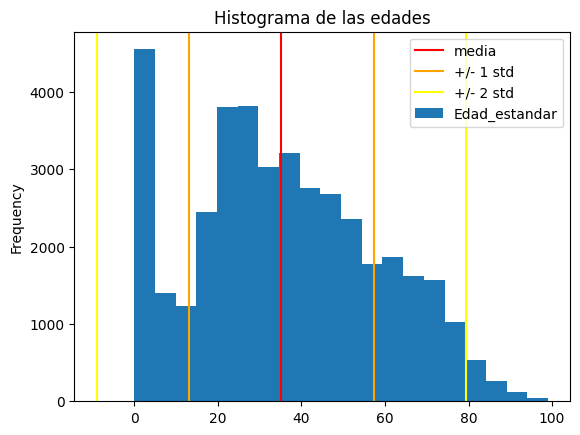

In [16]:
# graficas de las medidas estadísticas
mean = df['Edad_estandar'].mean()
std = df['Edad_estandar'].std()
plt.axvline(mean, color="red", label="media")
plt.axvline(mean+std, color="orange", label="+/- 1 std")
plt.axvline(mean-std, color="orange")
plt.axvline(mean+std*2, color="yellow", label="+/- 2 std")
plt.axvline(mean-std*2, color="yellow")
# grafica de la frecuencia de las edades
df['Edad_estandar'].plot.hist(bins=20, title="Histograma de las edades")
# Leyenda y mostrar gráfica
plt.legend()
plt.show()

Los ingresos diarios veamos la desviación estándar, 

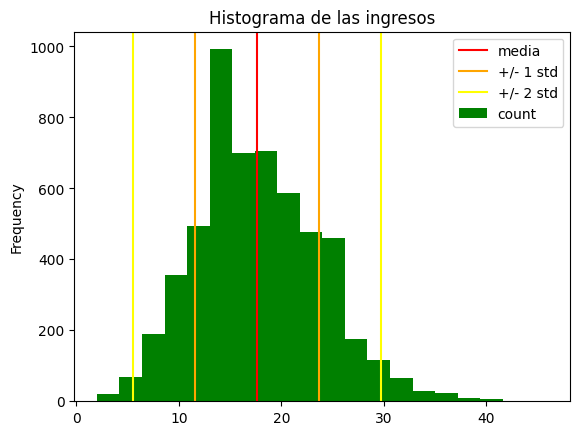

In [17]:
mean = ingresos_diarios.mean()
std = ingresos_diarios.std()
plt.axvline(mean, color="red", label="media")
plt.axvline(mean+std, color="orange", label="+/- 1 std")
plt.axvline(mean-std, color="orange")
plt.axvline(mean+std*2, color="yellow", label="+/- 2 std")
plt.axvline(mean-std*2, color="yellow")
# grafica de la frecuencia de las edades
ingresos_diarios.plot.hist(bins=20, color='g', title="Histograma de las ingresos")
# Leyenda y mostrar gráfica
plt.legend()
plt.show()

La **desviación mediana absoluta** (**MAD**, por _Median Absolute Deviation_) es una medida de dispersión que indica cuánto se desvían los valores de un conjunto de datos respecto a su mediana.

$$\operatorname {MAD} =\operatorname {mediana} (|X_{i}-{\tilde {X}}|)$$

Donde: $ \tilde{X}=mediana(X)$

Esta medida, junto con la mediana, es útil para tener una idea clara y robusta de la variabilidad, sobre todo cuando hay valores atípicos (outliers), porque no eleva las diferencias al cuadrado como la varianza.

Nota: la implementación de `scipy.stats` es sensible a los `nan`. Se recomienda limpiar los datos, pero también se puede usar:
`np.nanmedian(np.absolute(x - np.nanmedian(x)))`

In [18]:
stats.median_abs_deviation(df['Edad_estandar'].dropna())

np.float64(16.0)

Para los ingresos diarios

In [19]:
stats.median_abs_deviation(ingresos_diarios.dropna())

np.float64(4.0)

## 10.f Valores atípicos (outliers)

Un valor atípico (en inglés _outlier_) es una observación que es numéricamente distante del resto de los datos. 

En algunos casos, estos valores pueden ser errores de medición o datos incorrectos. En otros casos, pueden ser valores legítimos que reflejan una situación única o un evento excepcional. En cualquier caso, es importante examinar estos valores con cuidado para determinar su origen y su impacto en los resultados del análisis de los datos.

Una regla comúnmente utilizada para identificar outliers en una distribución normal es la "regla de las 3 desviaciones estándar". Según esta regla, cualquier valor que esté a más de 3 desviaciones estándar por encima o por debajo de la media se considera un outlier. Sin embargo, esta regla no siempre es aplicable a otras distribuciones o a situaciones en las que los datos tienen una distribución no normal.

Para detectar outliers, en primer lugar es útil hacer un análisis visual, utilizando un histograma, KDE o boxplot.

<Axes: title={'center': 'Edad'}>

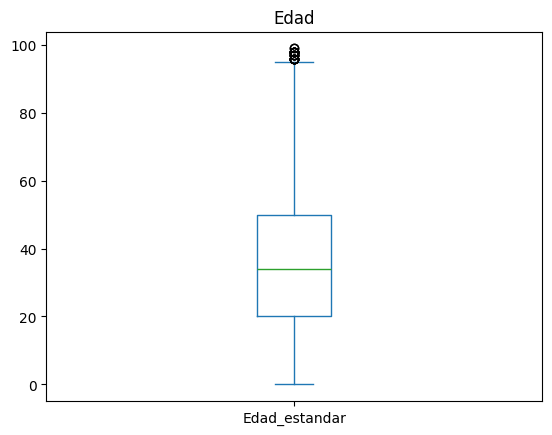

In [20]:
df['Edad_estandar'].plot.box(title='Edad')

Para los ingresos diarios

<Axes: title={'center': 'Ingresos diarios'}>

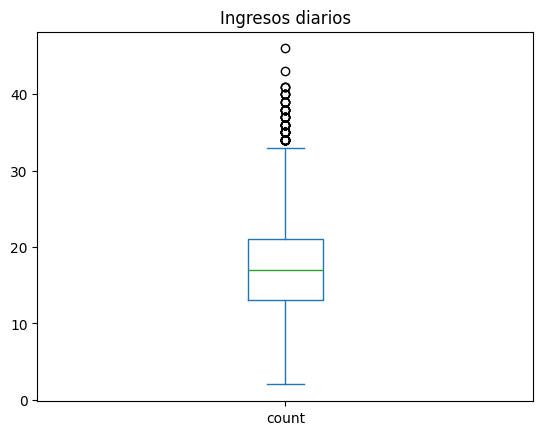

In [21]:
ingresos_diarios.plot.box(title='Ingresos diarios')

Una estrategia para determinar outliers es usar el **rango intercuartil** (IQR), el cual es la diferencia entre el tercer $Q3$ y el primer cuartil $Q1$ de una distribución ($IQR=Q3-Q1$). A partir de esto, se pueden definir los outliers como aquellos que son menores que $Q1–1.5\cdot IQR$ o mayores que $Q3 + 1.5\cdot IQR$


In [22]:
def get_outliers_IQR(s):
    q1=s.quantile(0.25)
    q3=s.quantile(0.75)
    IQR=q3-q1
    outliers = ((s<(q1-1.5*IQR)) | (s>(q3+1.5*IQR)))
    return outliers

df.loc[ get_outliers_IQR( df['Edad_estandar'] ), 'Edad_estandar']

33967    98.0
34574    98.0
40171    96.0
40789    97.0
41470    98.0
41923    98.0
43492    97.0
45803    96.0
46932    98.0
49742    99.0
53357    99.0
53923    97.0
54249    97.0
56179    96.0
57358    96.0
57776    96.0
62199    98.0
63700    98.0
64588    98.0
64869    96.0
68073    97.0
69028    97.0
69745    96.0
71652    98.0
71933    96.0
Name: Edad_estandar, dtype: float64

Para los ingresos diarios podemos notar que es muy común que los outliers sucedan en la última semana del año, asociados al incremento de accidentes en las fiestas.

In [23]:
ingresos_diarios[ get_outliers_IQR( ingresos_diarios ) ]

Fecha_estandar
1968-10-03    40
1969-12-26    38
1971-01-02    37
1973-10-29    37
1974-12-27    34
1975-01-02    34
1975-09-29    37
1975-12-26    39
1976-01-03    34
1976-01-26    35
1976-04-05    34
1977-04-19    41
1977-05-30    35
1977-06-13    35
1977-08-08    36
1977-12-15    39
1977-12-26    38
1978-09-17    40
1978-11-26    36
1978-12-25    36
1979-01-09    34
1979-08-06    35
1979-08-13    35
1979-08-20    34
1979-12-17    36
1979-12-26    43
1980-01-01    39
1980-03-03    39
1980-05-28    34
1980-06-10    34
1980-08-10    34
1980-08-18    36
1980-11-03    34
1980-11-30    37
1980-12-15    34
1980-12-22    34
1980-12-23    37
1981-01-21    36
1981-03-22    35
1981-03-24    40
1981-07-20    36
1981-07-28    35
1981-08-16    35
1981-11-19    38
1981-12-13    38
1981-12-14    38
1981-12-21    34
1981-12-26    41
1982-01-01    38
1982-01-02    34
1982-03-16    36
1982-03-27    46
1982-06-21    41
1982-07-26    34
1982-08-11    34
1982-09-19    37
1982-10-06    35
1982-10-11    35

En el caso de los valores categóricos se puede considerar que los valores atípicos son aquellos que tienen una frecuencia muy baja o muy alta.

Este valor se determina dependiendo del tipo de datos, pero generalmente se considera que un valor de baja frecuencia va de menos del 1 al 5% del porcentaje de los datos.  Se recomienda tomar en cuenta los datos faltantes al revisar esto.

Por ejemplo veamos la distribución de `Institución_origen`

<Axes: xlabel='Procedencia_estandar'>

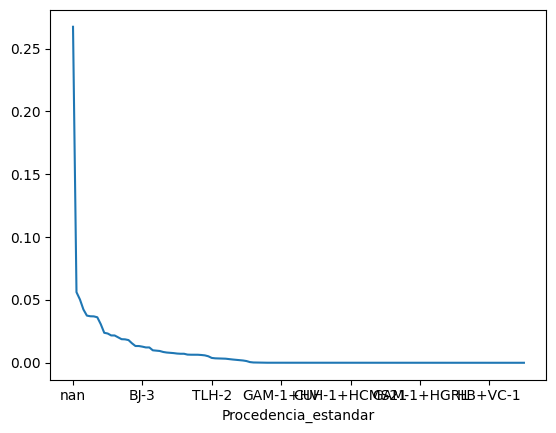

In [24]:
proce_freq = df['Procedencia_estandar'].value_counts(dropna=False, normalize=True)
proce_freq.plot()

En general, para detectar valores atípicos en variables categóricas es necesario tener un conocimiento profundo del contexto del análisis y de las posibles causas de la presencia de valores atípicos en los datos. También es importante utilizar varias técnicas de detección de outliers y comparar los resultados para tener una mayor confianza en las conclusiones.

Por ejemplo, calculemos cuantas procedencias con una frecuencia menor del 1% existen

In [25]:
len(proce_freq[proce_freq < 0.01])

108

Ahora, revisemos que porcentaje del total representan estas procedencias de baja frecuencia.

In [26]:
(proce_freq[proce_freq < 0.01]).sum()

np.float64(0.15943166329354422)

Como se puede ver, estas 108 procedencias de menos del 1% de frecuencia representan el 15.94% del total de las procedencias. Por lo tanto, es importante considerar cuidadosamente que se hará con ellas. Incluso, debemos de cuestionarnos si lo excepcional no son las procedencias de alta frecuencia.

## 10.g Pruebas de distribución

Verificar si un conjunto de datos sigue una distribución normal es fundamental en estadística, ya que muchas pruebas y modelos (como la regresión lineal, ANOVA o t-tests) suponen normalidad en los datos para que sus resultados sean válidos. Si esta condición no se cumple, se puede llegar a conclusiones erróneas, por lo que es clave evaluarla antes de aplicar estos métodos.

Una de las pruebas más utilizadas para este propósito es la prueba de **Shapiro-Wilk**. Esta prueba compara la distribución de los datos con la de una distribución normal teórica. 
La prueba regresa:
* **Estadístico (`stat`)**: estadístico principal de la prueba, mide cuánto se desvían tus datos de una distribución normal. Mientras más cercano a 1 más se parece a la distribución normal
* **valor p (`p`)**: indica la probabilidad de obtener un estadístico como ese (o más extremo), suponiendo que los datos sean normales. Si el valor p es menor que un nivel de significancia (por ejemplo, 0.05), se rechaza la hipótesis nula.

![Significancia estadistica](./images/xkcd_significant.png)

In [27]:
data = df['Edad_estandar'].dropna()
stat, p = stats.shapiro(data)
print(f'Estadístico={stat}, p-valor={p}')

Estadístico=0.9730263802129392, p-valor=6.902659911365208e-63


/home/esther/anaconda3/envs/CursoPandas2025/lib/python3.12/site-packages/scipy/stats/_axis_nan_policy.py:586: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 40156.
  res = hypotest_fun_out(*samples, **kwds)


En este caso, podemos ver que el estadístico es muy cercano a uno, mientras que el valor p es menor a 0.05, por lo que podemos concluir que la distribución cumple los criterios de normalidad.

Sin embargo, con toda prueba estadística, siempre es importante revisar las suposiciones, hipótesis y criterios.

Suposiciones de la prueba de Shapiro-Wilk:
* Datos independientes
* Variable continua (o casi continua)
* No hay valores extremos (outliers)
* **Tamaño de muestra entre 3 y 5000**

Hipótesis:
* Hipótesis nula ($H_0$): Los datos provienen de una distribución normal.
* Hipótesis alternativa ($H_1$): Los datos no provienen de una distribución normal.

Criterio de aceptación o rechazo
* Si p < 0.05 no se rechaza $H_0$, es decir, se acepta normalidad.
* Si p >= 0.05 se rechaza $H_0$, es decir, se rechaza normalidad.

En este caso no se cumple la suposición de tamaño de muestra, entonces es necesario buscar una prueba alternativa. En este caso usaremos Anderson-Darling

Suposiciones de la prueba de Anderson-Darling:
* Datos independientes
* Variable continua (o casi continua)
* No hay valores extremos (outliers)

Hipótesis:
* Hipótesis nula ($H_0$): Los datos provienen de una distribución normal.
* Hipótesis alternativa ($H_1$): Los datos no provienen de una distribución normal.

Criterio de aceptación/rechazo
* Se obtiene un estadístico de Anderson-Darling.
* Se compara con valores críticos para diferentes niveles de significancia (1%, 2.5%, 5%, 10%, 15%).
* Si el estadístico es mayor que el valor crítico para un nivel de significancia, se rechaza $H_0$ (los datos no son normales).
* Si el estadístico es menor que el valor crítico, no se rechaza$H_0$ (los datos podrían ser normales).

In [28]:
data = df['Edad_estandar'].dropna()
res = stats.anderson(data)

print(f'Estadístico de Anderson-Darling: {res.statistic:.4f}')

print("Valores críticos y niveles de significancia:")
for sl, cv in zip(res.significance_level, res.critical_values):
    print(f"  Nivel {sl}%: valor crítico = {cv}")

Estadístico de Anderson-Darling: 217.6051
Valores críticos y niveles de significancia:
  Nivel 15.0%: valor crítico = 0.576
  Nivel 10.0%: valor crítico = 0.656
  Nivel 5.0%: valor crítico = 0.787
  Nivel 2.5%: valor crítico = 0.918
  Nivel 1.0%: valor crítico = 1.092


En este caso, el estadístico es mucho mayor que el valor crítico, por lo que podemos rechazar la hipótesis nula, es decir, los datos de edad no son normales.

En conjuntos de datos grandes, es importante verificar visualmente usando un Q-Q-plot. Esto se debe a que, como ya vimos, muchas pruebas pueden mostrar problemas con conjuntos de datos grandes. Además, esta prueba nos permite determinar varios problemas con los datos.

El **Q-Q plot (Quantile-Quantile plot)** es una herramienta gráfica que compara la distribución de los datos con una distribución teórica (como la normal).
* Eje X: cuantiles teóricos (en este caso normal)
* Eje Y: cuantiles de los datos reales.



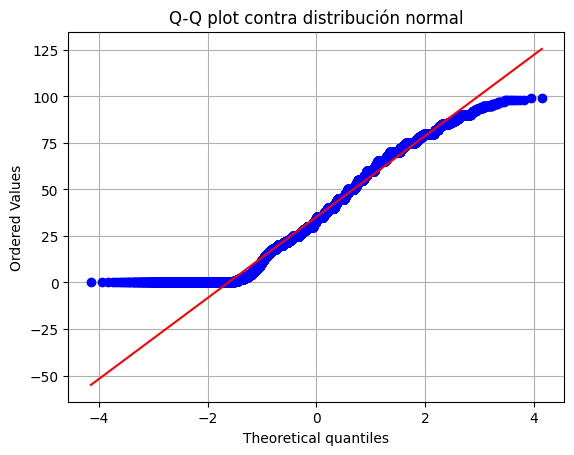

In [29]:
data = df['Edad_estandar'].dropna()
stats.probplot(data, dist="norm", plot=plt)
plt.title("Q-Q plot contra distribución normal")
plt.grid(True)
plt.show()

Revisando esta gráfica podemos determinar dos razones por las que los datos de `Edad_estandar` se desvían de la distribución normal.
* Hay muchas edades bajas
* Hay outliers o cola derecha pesada

En este caso, si se llevan a cabo pruebas estadísticas, es necesario usar pruebas no paramétrica. Sin embargo, ese es un tema que está más allá de este curso.

En el caso de los datos de ingresos por día, estos son eventos discretos, por lo que se deben de ajustar a una distribución discreta. Dado el tipo de datos y la gráfica es posible que la distribución sea Poisson. En este caso, es necesario estimar el parámetro lambda $\lambda$ es decir, la tasa media de ocurrencia de eventos en un intervalo fijo. En la práctica podemos usar la media de los datos como valor de $\lambda$.

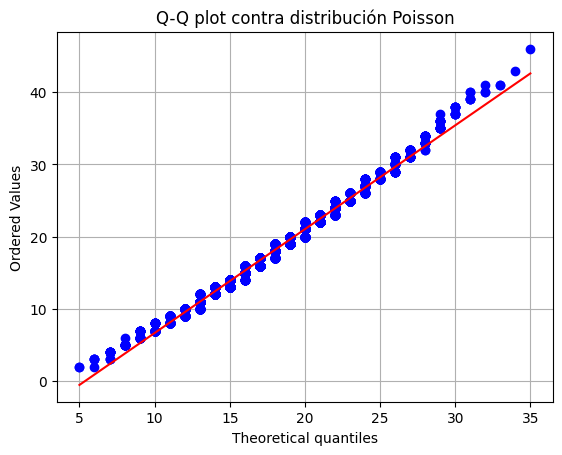

In [30]:
data = ingresos_diarios
l_data = ingresos_diarios.mean()
stats.probplot(data, dist="poisson", sparams=(l_data,), plot=plt)
plt.title("Q-Q plot contra distribución Poisson")
plt.grid(True)
plt.show()

En este caso, se puede notar que las colas no parecen ajustar perfectamente. El hacer la prueba estadística para ver si ajusta a una distribución de Poisson está fuera del alcance de este curso.

## 10.h Resumen

En esta lección hemos aprendido varios conceptos:

* Frecuencia `.value_counts().sort_index()`
* Distribuciones estadísticas:
    * Continuas: uniforme, normal, exponencial, bimodal, lognormal
    * Discretas: binomial, Poisson
* Promedio `.mean()`
* Mediana `.median()` ideal para datos con outliers
* Moda `.mode()`
* Asimetría `.skew()`
* Desviación estándar `.std()`
* Valores atípicos u outliers
    * Revisión visual
    * Rango interquartil IQR
* Para probar si un conjunto de datos tiene una distribución es necesario:
    * Prueba estadística
    * Visualizar con Q-Q plot
    * En conjuntos de datos grandes las pruebas estadísticas clásicas pueden fallar
* Al usar una prueba estadística es necesario revisar:
    * Suposiciones
    * Hipótesis
    * Criterio de aceptación 

**Gracias por su atención**